# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [3]:
df = pd.read_csv('data/df_furniture.csv')
df

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618
...,...,...
326,2019-03-01,9718.107698
327,2019-04-01,9248.814254
328,2019-05-01,10001.305304
329,2019-06-01,9431.337229


## 2. Tratar la fecha como texto e interpretar (parse)

In [4]:
df = pd.read_csv('data/df_furniture.csv', parse_dates = ['Month'], index_col = 'Month')
df.head()

,furniture_price_adjusted
Month,
1992-01-01,2073.432724
1992-02-01,2114.485812
1992-03-01,2260.570891
1992-04-01,2255.103236
1992-05-01,2331.414618


## 3. ¿De qué fecha a qué fecha va el histórico?

In [7]:
# De que fecha a que fecha tenemos datos?
print(f"Tenemos datos desde {df.index.min()} hasta {df.index.max()}")
df.info()

Tenemos datos desde 1992-01-01 00:00:00 hasta 2019-07-01 00:00:00
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 331 entries, 1992-01-01 to 2019-07-01
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   furniture_price_adjusted  331 non-null    float64
dtypes: float64(1)
memory usage: 5.2 KB


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

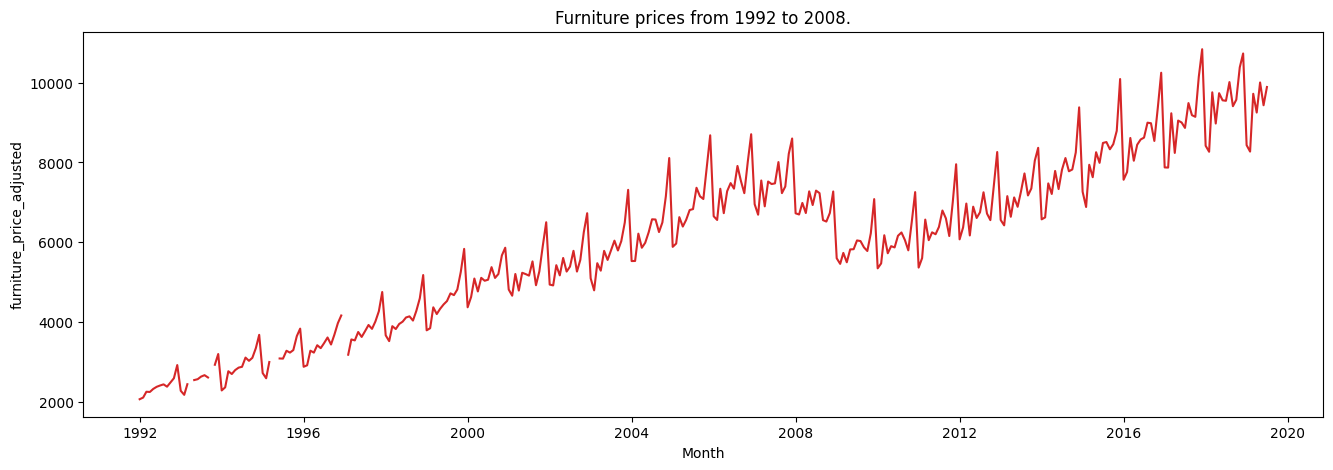

In [ ]:
import matplotlib.pyplot as plt

# Draw Plot
def plot_df(df, x, y, title="", xlabel='Month', ylabel='furniture_price_adjusted', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df.index, y=df.furniture_price_adjusted, title='Furniture prices from 1992 to 2008.') 

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

serie = df['furniture_price_adjusted']

# --- Prueba 1: Augmented Dickey-Fuller (ADF) ---
# H0: la serie tiene raíz unitaria (no es estacionaria)
# Si p-value > 0.05 → no podemos rechazar H0 → la serie NO es estacionaria
adf_result = adfuller(serie)
print('=== ADF Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Valores críticos: {adf_result[4]}')
if adf_result[1] > 0.05:
    print('→ p-value > 0.05: NO rechazamos H0. La serie NO es estacionaria.\n')
else:
    print('→ p-value <= 0.05: Rechazamos H0. La serie ES estacionaria.\n')

# --- Prueba 2: KPSS ---
# H0: la serie ES estacionaria (alrededor de una tendencia)
# Si p-value < 0.05 → rechazamos H0 → la serie NO es estacionaria
kpss_result = kpss(serie, regression='c', nlags='auto')
print('=== KPSS Test ===')
print(f'KPSS Statistic: {kpss_result[0]:.4f}')
print(f'p-value       : {kpss_result[1]:.4f}')
print(f'Valores críticos: {kpss_result[3]}')
if kpss_result[1] < 0.05:
    print('→ p-value < 0.05: Rechazamos H0. La serie NO es estacionaria.')
else:
    print('→ p-value >= 0.05: No rechazamos H0. La serie sería estacionaria.')

=== ADF Test ===
ADF Statistic : -1.1286
p-value       : 0.7036
Valores críticos: {'1%': np.float64(-3.4512146067362317), '5%': np.float64(-2.870730188960711), '10%': np.float64(-2.5716664849383113)}
→ p-value > 0.05: NO rechazamos H0. La serie NO es estacionaria.

=== KPSS Test ===
KPSS Statistic: 2.5552
p-value       : 0.0100
Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
→ p-value < 0.05: Rechazamos H0. La serie NO es estacionaria.


C:\Users\rns_2\AppData\Local\Temp\ipykernel_21312\2654799563.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(serie, regression='c', nlags='auto')


## 6. ¿Conoces algún método para representar mejor la tendencia?

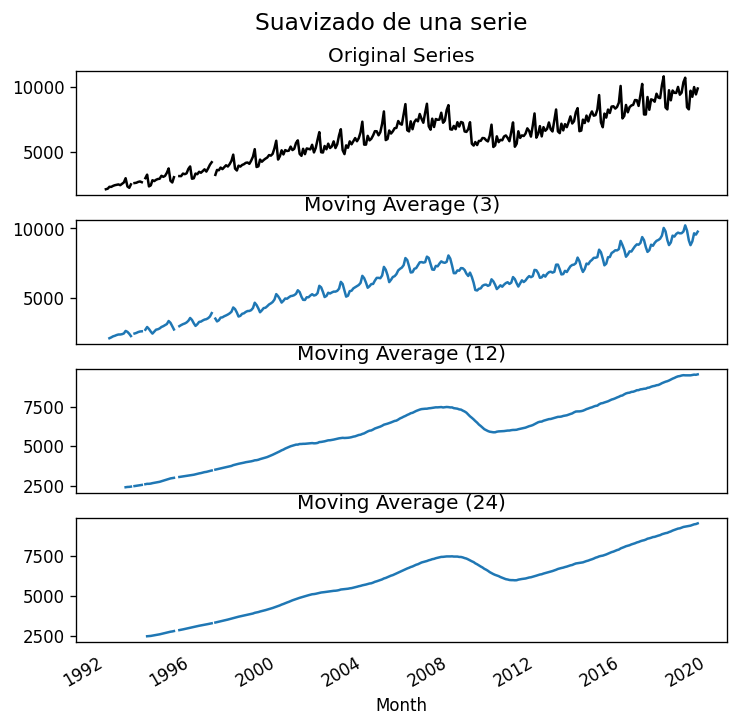

In [ ]:
plt.rcParams.update({'xtick.bottom' : False, 'axes.titlepad':5})

# Media móviles
df_ma = df.furniture_price_adjusted.rolling(3).mean()
df_ma_12 = df.furniture_price_adjusted.rolling(12).mean()
df_ma_24 = df.furniture_price_adjusted.rolling(24).mean()

# Plot
fig, axes = plt.subplots(4,1, figsize=(7, 7), sharex=True, dpi=120)
df['furniture_price_adjusted'].plot(ax=axes[0], color='k', title='Original Series')
df_ma.plot(ax=axes[1], title='Moving Average (3)')
df_ma_12.plot(ax=axes[2], title='Moving Average (12)')
df_ma_24.plot(ax=axes[3], title='Moving Average (24)')
fig.suptitle('Suavizado de una serie', y=0.95, fontsize=14)
plt.show()

In [ ]:
''' 
Con el suavizado de la serie podemos ver claramente la tendencia general de la serie, así como los patrones estacionales.
En este caso, la serie muestra una tendencia general al alza a lo largo del tiempo,
con picos estacionales que parecen ocurrir de manera regular cada año, lo que sugiere una fuerte estacionalidad anual en la serie.
'''

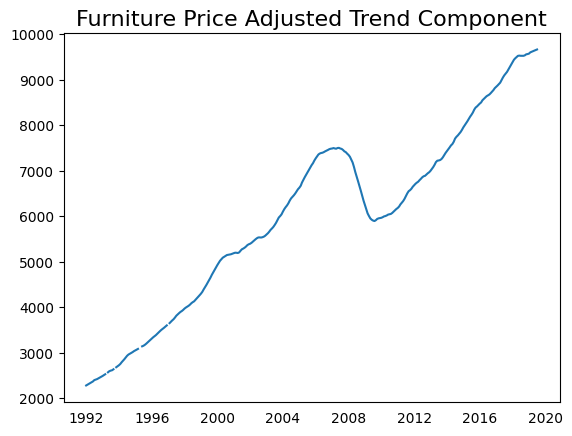

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result_add = seasonal_decompose(df['furniture_price_adjusted'], model='additive', period=12, extrapolate_trend='freq')

plt.plot(result_add.trend)
plt.title('Furniture Price Adjusted Trend Component', fontsize=16);

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

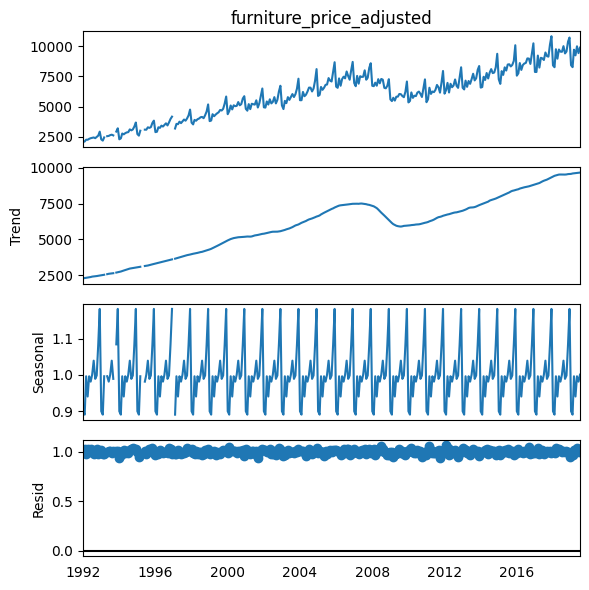

In [ ]:
# Descomposición
result_mul = seasonal_decompose(df['furniture_price_adjusted'], model = 'multiplicative', period=12, extrapolate_trend = 'freq')

# Plot
plt.rcParams.update({'figure.figsize': (6,6)})
result_mul.plot();

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

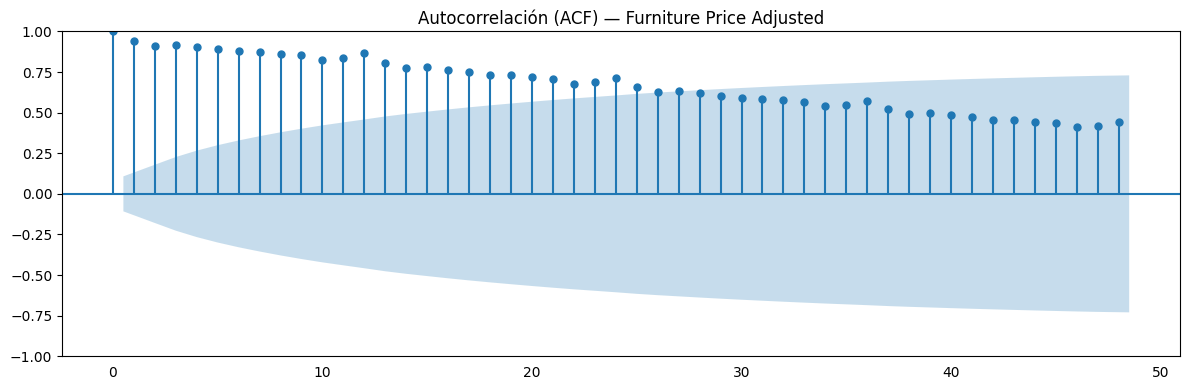

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# plot_acf recibe la SERIE ORIGINAL, no los valores de ACF ya calculados
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['furniture_price_adjusted'], lags=48, ax=ax)
ax.set_title('Autocorrelación (ACF) — Furniture Price Adjusted')
plt.tight_layout()
plt.show()

# La estacionalidad se aprecia en los picos que se repiten cada 12 lags (cada año)

In [ ]:
''' 
Podemos ver con esta grafica que la serie tiene una fuerte autocorrelación, lo que es normal en series temporales.
En este caso, la autocorrelación se mantiene alta incluso para lags grandes, lo que sugiere que los valores de la serie están fuertemente relacionados con sus valores pasados. 
Esto es típico en series temporales con tendencias o patrones estacionales, como parece ser el caso de esta serie de precios de muebles.
'''

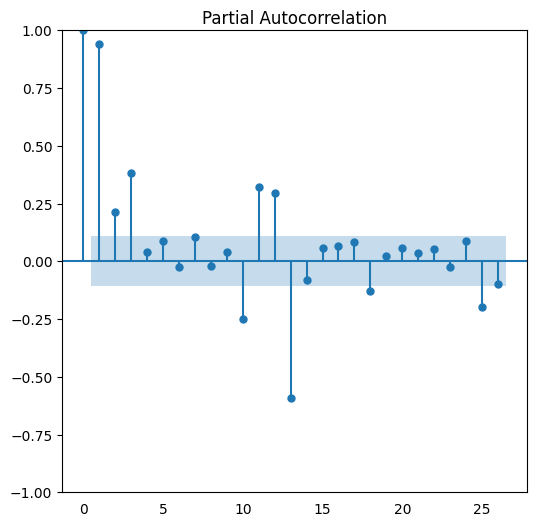

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['furniture_price_adjusted'].values);

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

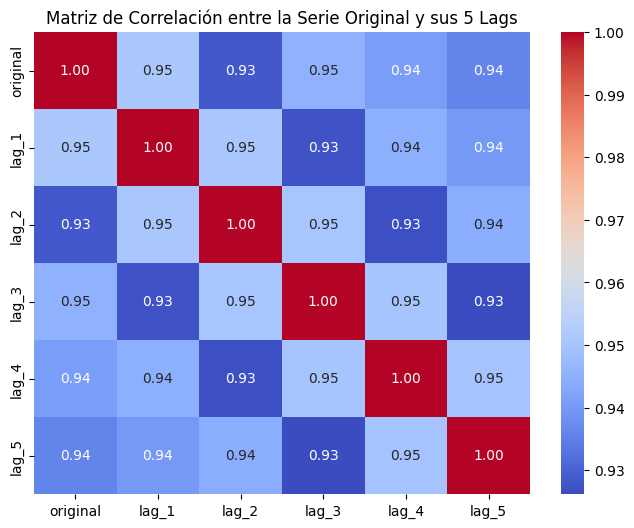

La matriz muestra la correlación entre la serie original y sus lags.
Valores altos de correlación (cerca de 1) indican fuerte dependencia temporal.
Esto es bueno para los modelos porque significa que el pasado influye en el presente,
lo que permite predicciones basadas en valores anteriores (ej. modelos ARIMA).


In [8]:
# Crear DataFrame con lags
lags = 5
df_lags = pd.DataFrame()
df_lags['original'] = df['furniture_price_adjusted']
for i in range(1, lags + 1):
    df_lags[f'lag_{i}'] = df['furniture_price_adjusted'].shift(i)

# Matriz de correlación
corr_matrix = df_lags.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre la Serie Original y sus 5 Lags')
plt.show()

# Explicación
print("La matriz muestra la correlación entre la serie original y sus lags.")
print("Valores altos de correlación (cerca de 1) indican fuerte dependencia temporal.")
print("Esto es bueno para los modelos porque significa que el pasado influye en el presente,")
print("lo que permite predicciones basadas en valores anteriores (ej. modelos ARIMA).")

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

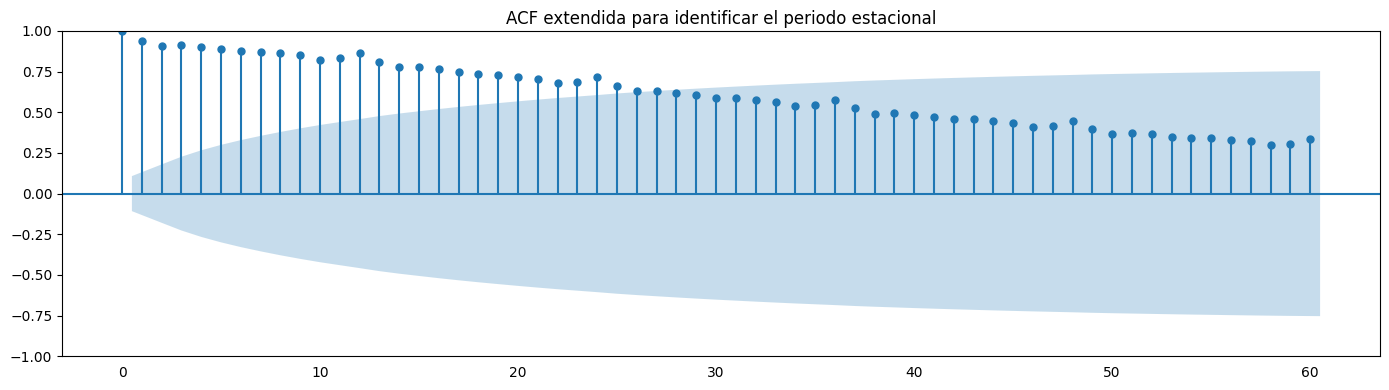

El lag con mayor autocorrelación es: 1
→ El patrón estacional se repite cada 1 instantes (meses), es decir, anualmente.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# Para identificar el periodo estacional miramos el gráfico ACF con muchos lags
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(df['furniture_price_adjusted'], lags=60, ax=ax)
ax.set_title('ACF extendida para identificar el periodo estacional')
plt.tight_layout()
plt.show()

# Comprobación numérica: buscamos el lag con mayor autocorrelación (ignorando lag 0)
from statsmodels.tsa.stattools import acf
acf_vals = acf(df['furniture_price_adjusted'], nlags=60)
periodo = acf_vals[1:].argmax() + 1  # +1 porque ignoramos el lag 0
print(f'El lag con mayor autocorrelación es: {periodo}')
print(f'→ El patrón estacional se repite cada {periodo} instantes (meses), es decir, anualmente.')

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

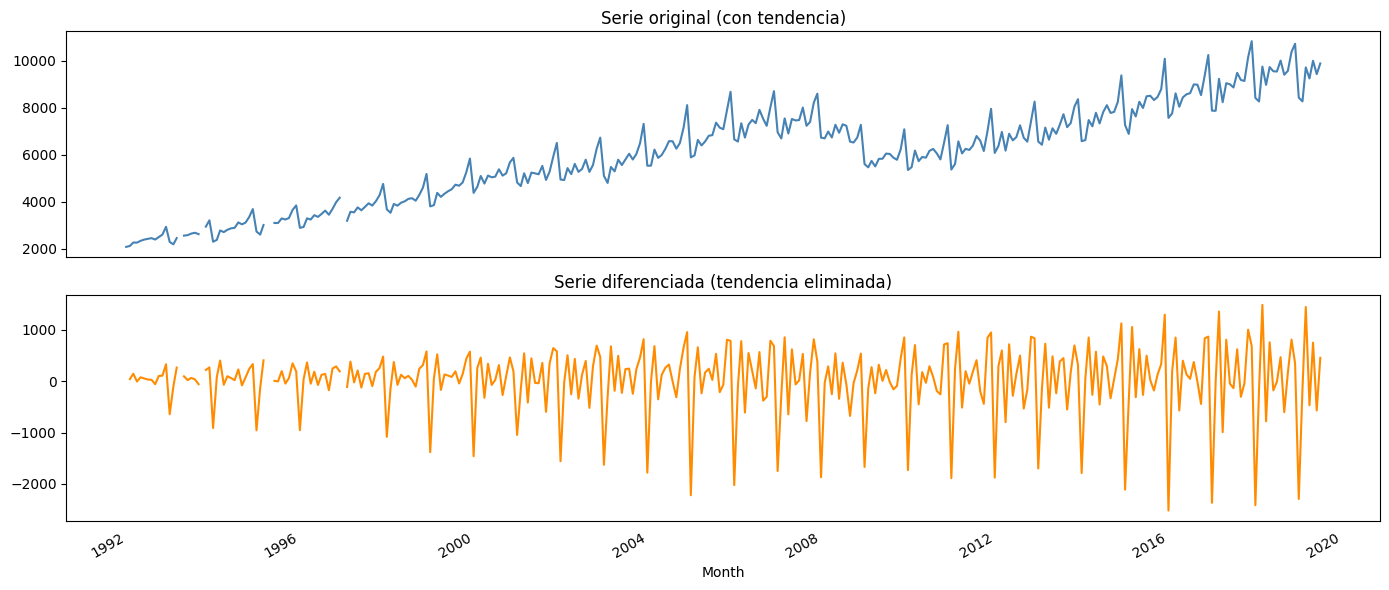

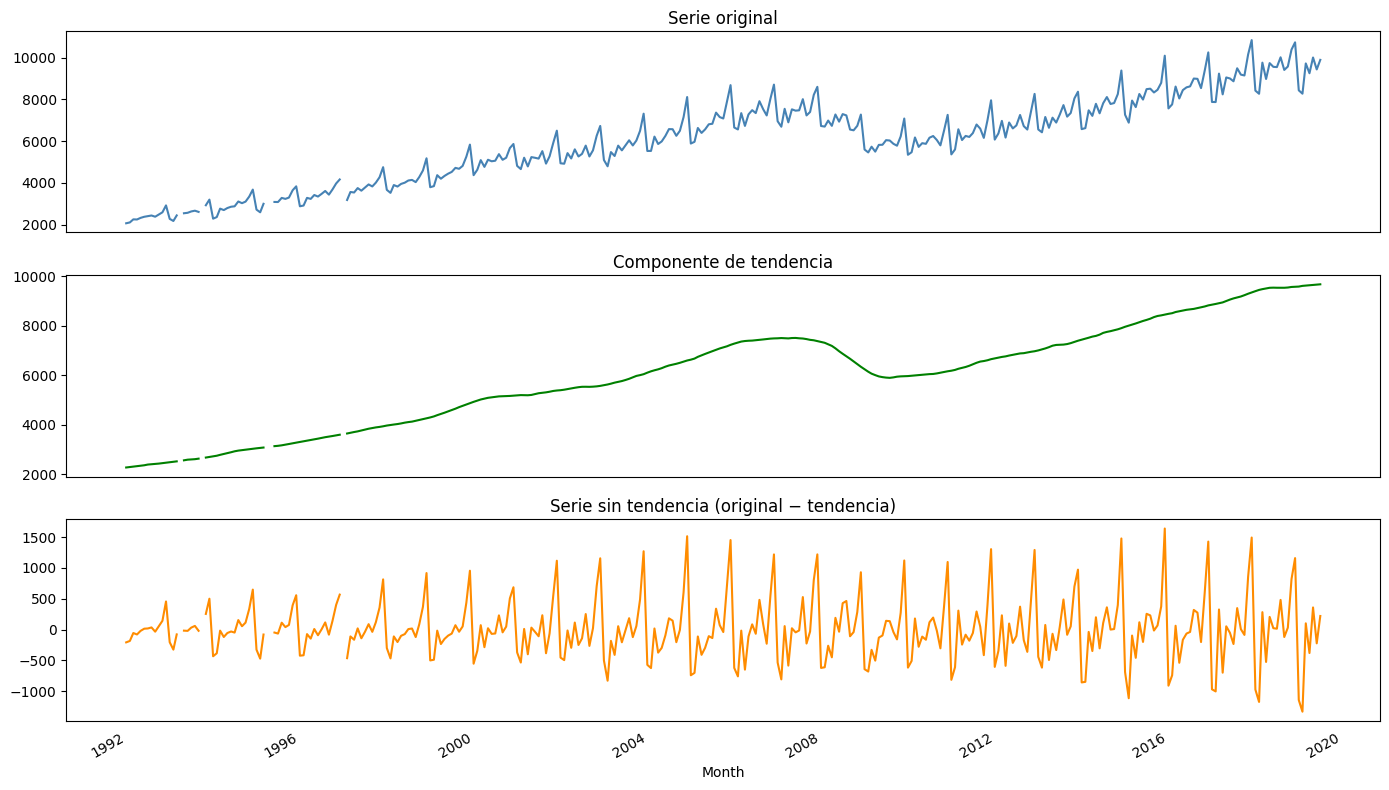

Ambos métodos permiten trabajar con una serie más estacionaria.
La diferenciación es más habitual antes de aplicar modelos ARIMA.
Restar la tendencia de la descomposición es útil para análisis exploratorio.


In [ ]:
# Hay varias formas de eliminar la tendencia. Las más habituales son:

# --- Método 1: Diferenciación ---
# Restamos el valor anterior a cada instante → eliminamos la tendencia lineal
df_diff = df['furniture_price_adjusted'].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
df['furniture_price_adjusted'].plot(ax=axes[0], title='Serie original (con tendencia)', color='steelblue')
df_diff.plot(ax=axes[1], title='Serie diferenciada (tendencia eliminada)', color='darkorange')
plt.tight_layout()
plt.show()

# --- Método 2: Restar la tendencia de la descomposición ---
# Usamos la descomposición aditiva para extraer la tendencia y restarla
from statsmodels.tsa.seasonal import seasonal_decompose

result_add = seasonal_decompose(df['furniture_price_adjusted'], model='additive', period=12, extrapolate_trend='freq')
df_sin_tendencia = df['furniture_price_adjusted'] - result_add.trend

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
df['furniture_price_adjusted'].plot(ax=axes[0], title='Serie original', color='steelblue')
result_add.trend.plot(ax=axes[1], title='Componente de tendencia', color='green')
df_sin_tendencia.plot(ax=axes[2], title='Serie sin tendencia (original − tendencia)', color='darkorange')
plt.tight_layout()
plt.show()

print('Ambos métodos permiten trabajar con una serie más estacionaria.')
print('La diferenciación es más habitual antes de aplicar modelos ARIMA.')
print('Restar la tendencia de la descomposición es útil para análisis exploratorio.')